# Experiments for $\operatorname{BE}(\alpha)$

## Imports and setup

In [32]:
from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt

## Agents

In [33]:
from abc import ABC, abstractmethod

class Agent(ABC):
    def __init__(self, K, name):
        self.K = K
        self.name = name

    @abstractmethod
    def pull(self):
        pass

    @abstractmethod
    def observe(self, reward):
        pass

### Random agent

In [34]:
class RandomAgent(Agent):
    def __init__(self, K, seed):
        super().__init__(K, 'Random agent')
        self.rng = np.random.default_rng(seed=seed)

    def pull(self):
        return self.rng.integers(1, self.K)

    def observe(self, reward):
        pass

### Windowed agent

In [35]:
class WindowedAgent(Agent):
    def __init__(self, K, name):
        super().__init__(K, name)
        self.w = 1
        self.d = 1

    @abstractmethod
    def _get_window_length(self):
        pass

    @abstractmethod
    def _reset_window(self):
        pass

    def _update_window(self):
        self.d += 1
        if self.d == self._get_window_length():
            self.w += 1
            self.d = 1
            self._reset_window()

#### $\operatorname{BE}(\alpha)$

In [36]:
class BEAlphaAgent(WindowedAgent):
    def __init__(self, K, alpha, sigma):
        super().__init__(K, '$\\operatorname{BE}(\\alpha)$')
        self.alpha = alpha
        self.sigma = sigma
        self._reset_window()

    def pull(self):
        self.last_pulled = min(self.B) + 1
        return self.last_pulled

    def observe(self, reward):
        self.S[self.last_pulled - 1] += reward
        self.B.remove(self.last_pulled - 1)

        if not self.B:
            self._eliminate_arms()

        super()._update_window()

    def _get_window_length(self):
        return np.ceil(self.w ** self.alpha)

    def _eliminate_arms(self):
        S_star = max([self.S[i] for i in self.A])
        delta_w = self._get_window_length()
        B_w = 2 * (1 + 2 * self.sigma * np.sqrt(delta_w * np.log(2 * self.K * delta_w)))
        self.B = {i for i in self.A if self.S[i] + B_w >= S_star}

    def _reset_window(self):
        self.S = [0.0] * self.K
        self.A = set(range(self.K))
        self.B = self.A.copy()

#### Rexp3

In [37]:
class Rexp3Agent(WindowedAgent):
    def __init__(self, K, delta, gamma, seed):
        super().__init__(K, 'Rexp3')
        self.delta = delta
        self.gamma = gamma
        self.rng = np.random.default_rng(seed=seed)
        self._reset_window()

    def pull(self):
        self.last_pulled = self.rng.choice(np.arange(1, self.K + 1), p=self.p)
        return self.last_pulled

    def observe(self, reward):
        self.weights[self.last_pulled - 1] *= np.exp(self.gamma / self.K * reward / self.p[self.last_pulled - 1])
        self._update_p()
        super()._update_window()

    def _get_window_length(self):
        return self.delta

    def _reset_window(self):
        self.weights = np.ones(self.K)
        self._update_p()

    def _update_p(self):
        self.p = (1 - self.gamma) * self.weights / np.sum(self.weights) + self.gamma / self.K
    
    @staticmethod
    def tune_delta(T, K, V_T):
        return np.ceil( (K * np.log(K)) ** (1/3) * (T/V_T) ** (2/3) )

    @staticmethod
    def tune_gamma(T, K, V_T):
        return min([1, np.sqrt(K * np.log(K) / (np.e - 1) / Rexp3Agent.tune_delta(T, K, V_T))])

### R-less-UCB

In [38]:
class RLessUCBAgent(Agent):
    def __init__(self, K, epsilon, alpha, sigma, initial_capacity=2**10):
        super().__init__(K, 'R-less-UCB')
        self.epsilon = epsilon
        self.alpha = alpha
        self.sigma = sigma
        self.initial_capacity = initial_capacity

        self.rewards = np.full((self.K, self.initial_capacity), np.nan)
        self.rewards_counts = np.zeros(self.K, dtype=int)
        self.preds = np.full(self.K, np.inf)
        self.ucbs = np.full(self.K, np.inf)
        self.t = 1

    def pull(self):
        self.last_pulled = np.argmax(self.ucbs) + 1
        return self.last_pulled

    def observe(self, reward):
        if self.rewards_counts[self.last_pulled - 1] >= self.rewards.shape[1]:
            self._expand_rewards()

        self.rewards[self.last_pulled - 1, self.rewards_counts[self.last_pulled - 1]] = reward
        self.rewards_counts[self.last_pulled - 1] += 1
        self.t += 1

        self._update_preds_ucbs()

    def _expand_rewards(self):
        new_capacity = self.rewards.shape[1] * 2
        new_rewards = np.full((self.K, new_capacity), np.nan)
        new_rewards[:, :self.rewards.shape[1]] = self.rewards
        self.rewards = new_rewards

    def _update_preds_ucbs(self):
        h = np.floor(self.epsilon * self.rewards_counts).astype(int)
        delta_t = self.t ** (-self.alpha)
        for i in range(self.K):
            if h[i] == 0:
                self.preds[i] = np.inf
                self.ucbs[i] = np.inf
                continue

            rewards_slice_1 = self.rewards[i, self.rewards_counts[i]-h[i]:self.rewards_counts[i]]
            rewards_slice_2 = self.rewards[i, self.rewards_counts[i]-2*h[i]:self.rewards_counts[i]-h[i]]
            rewards_diff = rewards_slice_1 - rewards_slice_2
            self.preds[i] = np.mean(rewards_slice_1 + (self.t - np.arange(self.rewards_counts[i]-h[i]+1, self.rewards_counts[i]+1))/h[i] * rewards_diff)
        
        self.ucbs[h > 0] = self.preds[h > 0] + self.sigma * (self.t - self.rewards_counts[h > 0] + h[h > 0] - 1) * np.sqrt(10 * np.log(1/delta_t) / (h[h > 0] ** 3))

## Instances

In [39]:
class Instance(ABC):
    def __init__(self, K):
        self.K = K

    @abstractmethod
    def next_payoffs(self):
        pass

### Random instance

In [40]:
class RandomInstance(Instance):
    def __init__(self, K, seed):
        super().__init__(K)
        self.rng = np.random.default_rng(seed=seed)

    def next_payoffs(self):
        return tuple(self.rng.uniform(0, 1) for _ in range(self.K))

### Exponential instance

In [41]:
class ExponentialInstance:
    def __init__(self, K, seed):
        self.K = K
        self.t = 1
        self.rng = np.random.default_rng(seed=seed)

        self.c = 1 - self.rng.random(K)
        self.a = 1 - self.rng.random(K)

    def next_payoffs(self):
        payoffs = self.c * (1 - np.exp(-self.a * self.t))
        self.t += 1
        return payoffs

## Runs

In [42]:
def run(K, T, agent, instance, sigma, seed):
    rng = np.random.default_rng(seed=seed)
    cumulative_regret = np.zeros(T+1)

    for t in range(1, T + 1):
        payoffs = instance.next_payoffs()

        arm = agent.pull()
        arm_index = arm - 1

        noise = rng.normal(0, sigma)
        reward = payoffs[arm_index] + noise

        agent.observe(reward)

        best_payoff = max(payoffs)
        instantaneous_regret = best_payoff - payoffs[arm_index]
        cumulative_regret[t] = cumulative_regret[t-1] + instantaneous_regret

    return cumulative_regret[1:]


In [43]:
def compare_agents(K, T, agents, instance, sigma, n_runs, seed):
    cumulative_regrets_avg_std = dict()

    for agent in agents:
        cumulative_regrets = np.zeros((n_runs, T))

        for r in range(n_runs):
            cumulative_regrets[r, :] = run(K, T, agent, instance, sigma, seed+r)

        cumulative_regrets_avg_std[agent.name] = (np.mean(cumulative_regrets, axis=0), np.std(cumulative_regrets, axis=0))

    return cumulative_regrets_avg_std

def plot_comparison(cumulative_regrets_avg_std, plot_horizon):
    agents_names = cumulative_regrets_avg_std.keys()

    plt.figure(figsize=(10, 6))

    # Plot each agent's performance
    for agent_name in agents_names:
        plt.plot(np.arange(plot_horizon), cumulative_regrets_avg_std[agent_name][0][:plot_horizon], label=f'{agent_name}', linewidth=2)
        plt.fill_between(np.arange(plot_horizon), cumulative_regrets_avg_std[agent_name][0][:plot_horizon] - cumulative_regrets_avg_std[agent_name][1][:plot_horizon],
                         cumulative_regrets_avg_std[agent_name][0][:plot_horizon] + cumulative_regrets_avg_std[agent_name][1][:plot_horizon],
                         alpha=0.2)

    plt.xlabel("round (t)")
    plt.ylabel("Cumulative Regret")
    plt.title("Comparison of Multiple Agents")
    plt.legend()
    plt.grid(True)
    plt.show()

### Sanity check

In [44]:
K = 5
T = 1000
SIGMA = 0.1
N_RUNS = 10
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=0.5, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=100, gamma=0.1, seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.1, alpha=3, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent]

instance = RandomInstance(K=K, seed=SEED)

cumulative_regrets_avg_std = compare_agents(K=K, T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

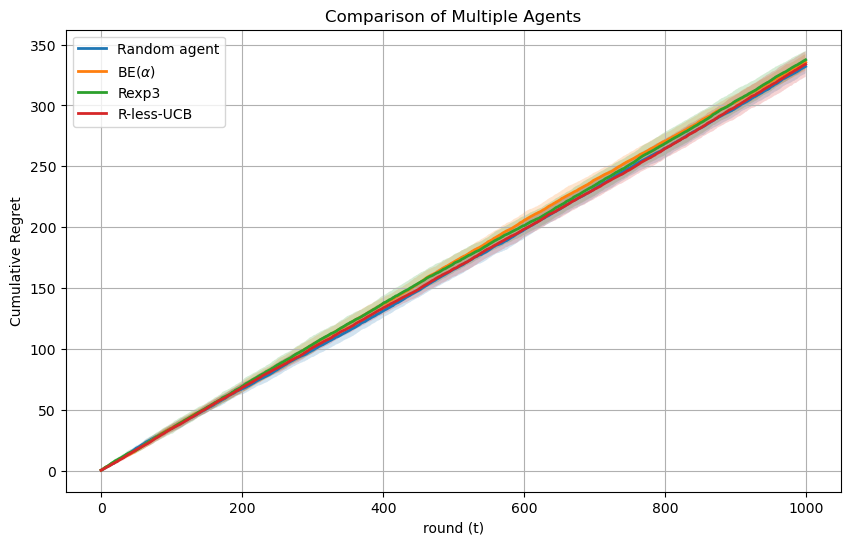

In [45]:
plot_comparison(cumulative_regrets_avg_std, T)

### Experiment on the exponential instance

In [50]:
K = 15
T = 10000
SIGMA = 0.1
N_RUNS = 10
SEED = 42

random_agent = RandomAgent(K=K, seed=SEED)
bealpha_agent = BEAlphaAgent(K=K, alpha=8/3, sigma=SIGMA)
rexpr3_agent = Rexp3Agent(K=K, delta=Rexp3Agent.tune_delta(T, K, K), gamma=Rexp3Agent.tune_gamma(T, K, K), seed=SEED)
rlessucb_agent = RLessUCBAgent(K=K, epsilon=0.25, alpha=2.1, sigma=SIGMA)
agents = [random_agent, bealpha_agent, rexpr3_agent, rlessucb_agent]

instance = ExponentialInstance(K=K, seed=SEED)

cumulative_regrets_avg_std = compare_agents(K=K, T=T, agents=agents, instance=instance, sigma=SIGMA, n_runs=N_RUNS, seed=SEED)

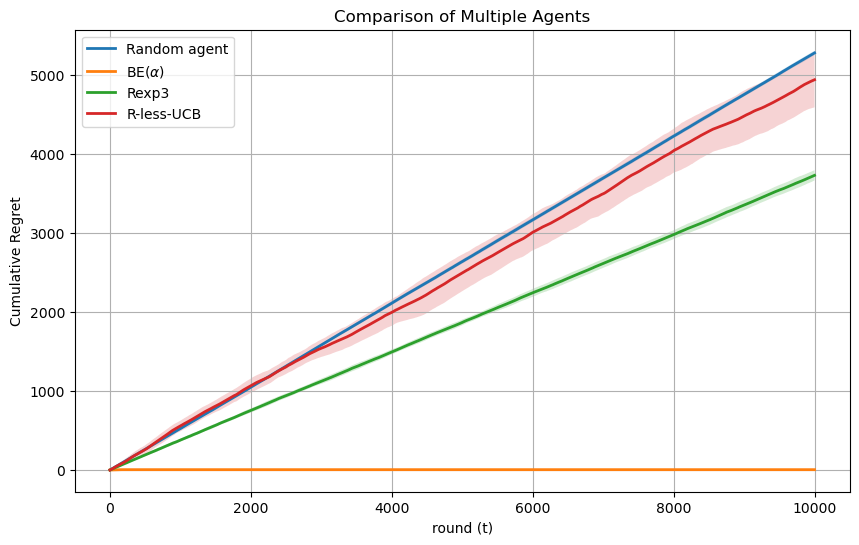

In [51]:
plot_comparison(cumulative_regrets_avg_std, T)